# SHAP-IMV — Breast Cancer (Wisconsin Diagnostic)

Exact Shapley attribution with IMV as the coalition value (binary: malignant).

This dataset is small and highly separable, so likelihoods sit close to 1. That
makes it the best example of why the inverse-entropy upper bound matters: the
retired 0.999 cap would have pinned distinct models to one weight.

**Pipeline**: download from UCI → select six mean-geometry features →
standardise → 10 seeds × 3 estimators × exact power set → aggregate.

Full documentation: `documentation/examples/shap_imv/breast_cancer.md`.

In [1]:
import os, sys, tempfile, warnings, itertools
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# No dataset is stored in this repository. Everything downloads on demand into a
# user-level cache outside the working tree.
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
CACHE.mkdir(parents=True, exist_ok=True)

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "shap_imv_breast_cancer"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

# Ten seeds, as required for any reported IMV result. The seed drives the fold
# split and the estimator, so every number below is a mean over ten independent
# fold partitions.
SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
N_SPLITS = 5

import imv
from imv import BinaryIMV
from imv.utils import save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")


imv 1.2.0 from src/imv


## 1. Download

Nothing is read from the repository.

In [2]:
from ucimlrepo import fetch_ucirepo
DATASET, TITLE = "breast_cancer", "Breast Cancer"
raw = fetch_ucirepo(id=17)
frame = raw.data.features.copy()
frame["target"] = (raw.data.targets.iloc[:, 0].astype(str).str.strip() == "M").astype(int)
print(frame.shape, frame["target"].value_counts().to_dict())
frame.head()

(569, 31) {0: 357, 1: 212}


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 2. Preprocess

Every transformation is applied here and stated in the docs.

In [3]:
# The 30 columns are three statistics over ten geometric measurements. We keep the
# six "mean" columns that are least collinear, since exact enumeration is 2**n.
FEATURES = ["radius1", "texture1", "smoothness1", "compactness1",
            "symmetry1", "fractal_dimension1"]
missing = [c for c in FEATURES if c not in frame.columns]
if missing:                      # column naming varies between UCI mirrors
    FEATURES = [c for c in frame.columns if c != "target"][:6]
data = frame[FEATURES + ["target"]].apply(pd.to_numeric, errors="coerce").dropna()
print(data.shape, FEATURES)
data.head()

(569, 7) ['radius1', 'texture1', 'smoothness1', 'compactness1', 'symmetry1', 'fractal_dimension1']


,radius1,texture1,smoothness1,compactness1,symmetry1,fractal_dimension1,target
0,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1
1,20.57,17.77,0.08474,0.07864,0.1812,0.05667,1
2,19.69,21.25,0.10960,0.15990,0.2069,0.05999,1
3,11.42,20.38,0.14250,0.28390,0.2597,0.09744,1
4,20.29,14.34,0.10030,0.13280,0.1809,0.05883,1


## 3. Estimators and budget

In [4]:
# Exact SHAP-IMV enumerates every feature subset, so cost is
# 2**n_features * n_splits * 2 fits per seed per estimator. That total is driven by
# the coalition count, not the row count, so every example runs on the full dataset
# and the budget is spent on parallelism instead: N_JOBS spreads the 2**n
# coalitions across cores.
N_JOBS = 11

def model_factories(seed):
    """Three estimator families, deliberately small so the exact power set is affordable."""
    return {
        "logistic_regression": lambda: LogisticRegression(max_iter=5000, random_state=seed),
        "xgboost": lambda: XGBClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbosity=0, tree_method="hist", n_jobs=1),
        "lightgbm": lambda: LGBMClassifier(
            n_estimators=60, max_depth=3, learning_rate=0.2, random_state=seed,
            verbose=-1, n_jobs=1),
    }


## 4. Exact SHAP-IMV over ten seeds

Each value is a mean over ten independent fold partitions; `std` is the spread across seeds, which describes stability and is **not** a confidence interval.

In [5]:
# Features are standardised because IMV reads probabilities, and unscaled inputs
# leave logistic regression unconverged, which would score a half-optimised model.
def scaled(frame, features):
    out = frame.copy()
    out[features] = StandardScaler().fit_transform(out[features])
    return out

# Standardisation is fit once on the full dataset: with no row subsampling the
# seed no longer selects rows, only the fold partition and the estimator.
frame = scaled(data, FEATURES)

records = []
for seed in SEEDS:
    for name, factory in model_factories(seed).items():
        evaluator = BinaryIMV(
            frame, "target", FEATURES, factory,
            split_method="stratified_kfold", n_splits=N_SPLITS,
            random_seed=seed, n_jobs=N_JOBS,
        )
        evaluator.run_evaluation()
        for feature in FEATURES:
            records.append({
                "seed": seed, "model": name, "feature": feature,
                "shap_imv": evaluator.calculate_imvshapley_value(feature),
            })
        records.append({
            "seed": seed, "model": name, "feature": "__full_model_imv__",
            "shap_imv": evaluator.all_combinations_imv[tuple(FEATURES)][0],
        })

raw = pd.DataFrame(records)
raw.to_csv(RESULTS / f"{DATASET}_shap_imv_by_seed.csv", index=False)
summary = (raw[raw.feature != "__full_model_imv__"]
           .groupby(["model", "feature"])["shap_imv"]
           .agg(["mean", "std"]).reset_index()
           .sort_values(["model", "mean"], ascending=[True, False]))
summary.to_csv(RESULTS / f"{DATASET}_shap_imv_summary.csv", index=False)
summary


  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

  0%|          | 0/64 [00:00<?, ?it/s]

,model,feature,mean,std
2,lightgbm,radius1,0.2290,0.007102
0,lightgbm,compactness1,0.1271,0.006262
5,lightgbm,texture1,0.0744,0.005892
3,lightgbm,smoothness1,0.0462,0.004894
1,lightgbm,fractal_dimension1,0.0228,0.007913
4,lightgbm,symmetry1,0.0195,0.008436
8,logistic_regression,radius1,0.2172,0.002898
6,logistic_regression,compactness1,0.1307,0.001703
11,logistic_regression,texture1,0.0696,0.002797
9,logistic_regression,smoothness1,0.0504,0.001075


## 5. Figure

A negative bar means the feature *reduced* held-out information — it does not indicate the negative class.

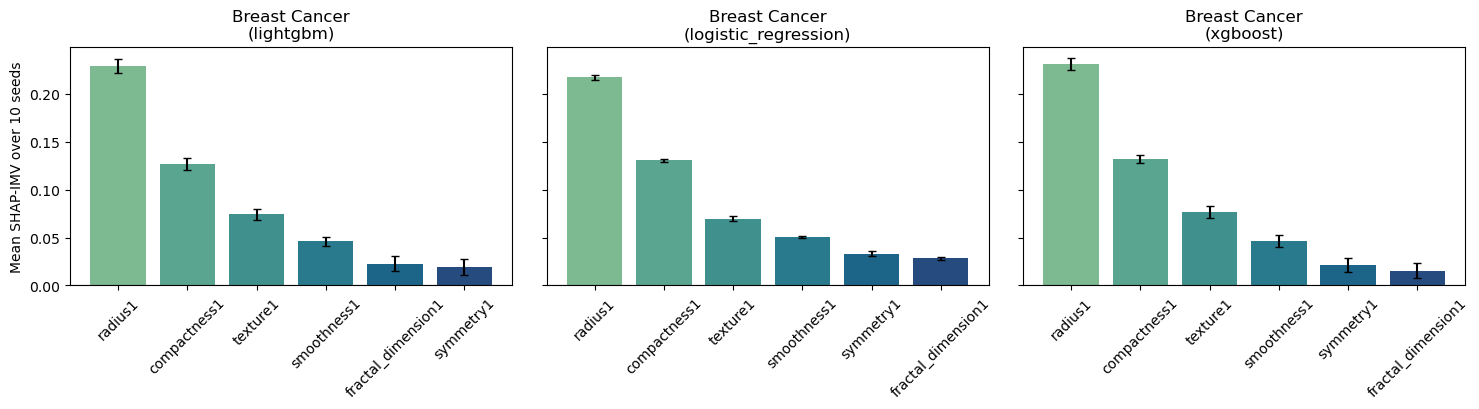

{'png': 'figures/breast_cancer_shap_imv.png',
 'pdf': 'figures/breast_cancer_shap_imv.pdf',
 'svg': 'figures/breast_cancer_shap_imv.svg'}

In [6]:
models = list(summary["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, models):
    part = summary[summary.model == name].sort_values("mean", ascending=False)
    ax.bar(part["feature"], part["mean"], yerr=part["std"].fillna(0),
           capsize=3, color=sns.color_palette("crest", len(part)))
    ax.set_title(f"{TITLE}\n({name})")
    ax.tick_params(axis="x", rotation=45)
    ax.axhline(0, color="0.4", linewidth=0.8)
axes[0].set_ylabel(f"Mean SHAP-IMV over {len(SEEDS)} seeds")
fig.tight_layout()
paths = {file_format: relative_path(path, start=ARTIFACTS)
         for file_format, path in save_figure(
             fig, FIGURES / f"{DATASET}_shap_imv"
         ).items()}
plt.show()
paths
